In [1]:
%load_ext autoreload
%autoreload 2

import os, sys

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

In [2]:
from progsnap2.datasets import cs1eng, codeworkout, codebench, edwards

# Select a dataset by setting the config variable
# config = cs1eng.S24
config = codeworkout.F19
# config = codebench.F24
# config = edwards.F21


dataset_name, dataset_semester = config.name.split('_')
dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)
dataset = config.load(dataset_root_dir)

In [17]:
# Just get the first few thousand rows for testing and quicker loading
sample_size = 100000
# main_table_sample = dataset.get_main_table_head(sample_size)
main_table_sample = dataset.get_main_table()
# main_table_sample

In [18]:
most_common_problem = main_table_sample[Cols.ProblemID].value_counts().idxmax()
most_common_problem

np.int64(13)

In [19]:
problem_subset = main_table_sample[main_table_sample[Cols.ProblemID] == most_common_problem]
problem_subset[Cols.SubjectID].nunique()

500

In [20]:
if not config.name.startswith('edwards'):
    problem_subset = problem_subset[problem_subset[Cols.CodeStateID].notna()]
    problem_subset

In [21]:
problem_subset[Cols.EventID].diff().describe()

count    19222.000000
mean         9.857923
std        665.739508
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      92171.000000
Name: EventID, dtype: float64

In [42]:
final_submissions = problem_subset[problem_subset.Score.notna()].groupby(Cols.SubjectID).tail(1)
final_submissions.shape

(500, 18)

In [43]:
problem_codestates = dataset.get_codestates(final_submissions)
problem_codestates.head()

,CodeStateID,Code
10,59f49ef818164f4ed3a6fa8a5585c8264097992de976cd...,"public int caughtSpeeding(int speed, boolean i..."
48,90173bc542cf7ce1e5ed8f2bdf2af687df6cbfdc652bcb...,"public int caughtSpeeding(int speed, boolean i..."
91,8924cb4007a948806c276c560147605f93fa867fdfcf4b...,"public int caughtSpeeding(int speed, boolean i..."
140,64754120f1058105e4e1ade363e971e3d6902cce4a1cc7...,"public int caughtSpeeding(int speed, boolean i..."
295,bd02f9b4998cc07e4373473310d2c967af7369cd35056c...,"public int caughtSpeeding(int speed, boolean i..."


In [44]:
problem_codestates.shape

(500, 2)

In [45]:
logs_with_code = pd.merge(
    final_submissions,
    problem_codestates,
    on=Cols.CodeStateID,
)
logs_with_code.shape

(500, 19)

In [46]:
from progsnap2.analytics.analytics_config import ProgrammingLanguage
from progsnap2.analytics.code.python.clean import CleanPythonPreprocessor
from progsnap2.spec.enums import CodeStatesTableColumns as CodeCols

if config.programming_language == ProgrammingLanguage.Python:
    cleaner = CleanPythonPreprocessor()

    cleaned_codestates = cleaner.fit_transform(logs_with_code[CodeCols.Code])
    for i in range(2):
        print(f"Original:\n{logs_with_code.iloc[i][CodeCols.Code]}")
        print(f"Cleaned:\n{cleaned_codestates[i]}")
        print()
else:
    print("No cleaner available for this programming language.")
    cleaned_codestates = logs_with_code[CodeCols.Code]

No cleaner available for this programming language.


In [47]:
from sklearn.feature_extraction.text import CountVectorizer
token_pattern = r"[\w]+|[^\s]|[ ]{4}"
ngram_range = (1,3)
vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=token_pattern,
    ngram_range=ngram_range
)

X = vectorizer.fit_transform(cleaned_codestates)
X.shape

(500, 2744)

In [48]:
# Convert to 2D using TSNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X.toarray())
X_tsne

array([[ 4.72695351e+00, -1.12154377e+00],
       [ 1.69945259e+01, -8.51739311e+00],
       [ 3.09809055e+01,  9.94382083e-01],
       [ 2.16663494e+01, -8.11295891e+00],
       [ 4.24456692e+00,  5.41850376e+00],
       [-6.19615936e+00,  3.68620366e-01],
       [-1.63022308e+01,  4.51405668e+00],
       [ 2.05497208e+01, -8.97538567e+00],
       [ 1.10221758e+01,  1.08463824e+00],
       [-6.93691730e+00,  4.39858150e+00],
       [-4.14608049e+00, -4.87035227e+00],
       [ 2.17980480e+01, -9.46356869e+00],
       [ 9.19620228e+00, -9.39492798e+00],
       [ 2.99448700e+01, -8.63856077e-02],
       [ 2.71866679e+00,  5.66663122e+00],
       [-1.11374598e+01,  4.38714409e+00],
       [ 1.09017191e+01, -8.88098717e+00],
       [-1.56570415e+01,  2.82213998e+00],
       [ 3.07769852e+01, -1.31092536e+00],
       [-1.60516968e+01,  2.43023443e+00],
       [ 2.02236786e+01, -7.41696978e+00],
       [ 2.98514462e+01,  1.27321160e+00],
       [ 2.11449871e+01, -9.09168053e+00],
       [-1.

<Axes: >

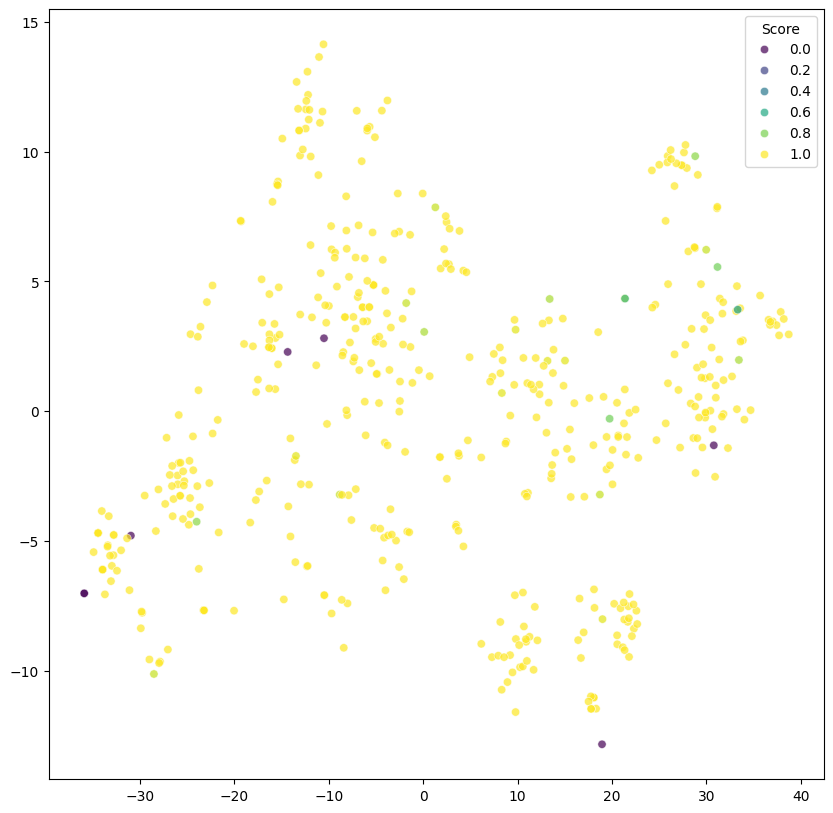

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=logs_with_code[Cols.Score], palette='viridis', alpha=0.7)

In [52]:
grade_col = config.final_grade_column
grades = dataset.get_link_table(config.grades_link_table_name)[[Cols.SubjectID, grade_col]]

In [ ]:
logs_with_grades = logs_with_code.merge(grades, on=Cols.SubjectID, how='left')
# Remove 0s, since they are usually not earned grades
logs_with_grades[grade_col] = logs_with_grades[grade_col].map(lambda x: x if x > 0 else pd.NA)
logs_with_grades.shape

(500, 20)

<Axes: >

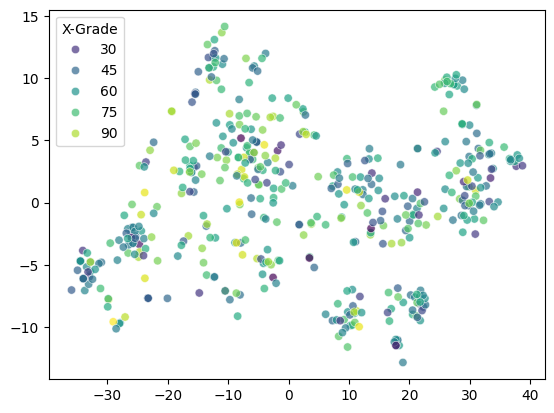

In [58]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=logs_with_grades[grade_col], palette='viridis', alpha=0.7)

In [73]:
from sklearn.neighbors import KNeighborsRegressor

no_na_rows = logs_with_grades[grade_col].notna()

# Use CV to evaluate a KNN regressor on the vectorized code to predict the final grade
from sklearn.model_selection import cross_val_score
knn = KNeighborsRegressor()
scores = cross_val_score(knn, X_tsne[no_na_rows,:], logs_with_grades.loc[no_na_rows, grade_col], cv=5, scoring='neg_mean_squared_error')
scores

array([-367.25104971, -332.70900069, -382.99426049, -365.55252951,
       -307.22633897])

In [72]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
cross_val_score(dummy, X.toarray()[no_na_rows,:], logs_with_grades.loc[no_na_rows, grade_col], cv=5, scoring='neg_mean_squared_error')


array([-362.33168686, -317.35058085, -321.11043163, -274.22259592,
       -300.48117649])

In [76]:
from sklearn.linear_model import LassoCV
lasso = LassoCV()
cross_val_score(lasso, X_tsne[no_na_rows,:], logs_with_grades.loc[no_na_rows, grade_col], cv=5, scoring='neg_mean_squared_error')


array([-355.597229  , -319.45245361, -310.87841797, -272.19390869,
       -301.92749023])

In [80]:
from progsnap2.analytics.metrics.time import TimeMetrics

In [82]:
from progsnap2.analytics.analytics_config import Granularity

idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")

In [83]:
time_metrics_calculator = TimeMetrics(idle_gap, break_gap, True, config.primary_timestamp_column)
time_metrics = problem_subset.groupby(Cols.SubjectID).apply(lambda x: time_metrics_calculator.calculate(x))
time_metrics

C:\Users\twprice\AppData\Local\Temp\ipykernel_35912\3257658621.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_metrics = problem_subset.groupby(Cols.SubjectID).apply(lambda x: time_metrics_calculator.calculate(x))


,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
SubjectID,,,,,,,,
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc,455.0,0.0,455.0,0.0,0,2019-09-27 11:29:04,2019-09-27 11:36:39,2019-09-27 11:36:39
014604ba54339d4b1266cf78e125053a5ac11dd861ef3cc0b4ed777ed0e2af0a,0.0,0.0,0.0,0.0,0,2019-09-30 17:33:24,2019-09-30 17:33:24,2019-09-30 18:12:48
01e96e066eff2e82627dac0493737be2de9bd2f50d6d498bb6420906c7164c05,591.0,303.0,894.0,0.0,0,2019-09-27 05:25:13,2019-09-27 05:40:07,2019-09-27 05:40:07
03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b08b27be1fb7638cc466,55.0,0.0,55.0,0.0,1,2019-09-28 01:47:17,2019-09-28 03:57:41,2019-09-28 03:57:41
0461c96c9cc0058f709704605f24136f373ba4e9ac083a1157d0976f1b6e8419,504.0,0.0,504.0,0.0,3,2019-09-25 15:29:38,2019-09-26 18:39:11,2019-09-26 18:39:11
...,...,...,...,...,...,...,...,...
fe545219144abfb405c64d3fed4f32dc348ece7afb0a814e646ef2f17e69bc7d,58.0,0.0,58.0,0.0,0,2019-09-30 17:50:10,2019-09-30 17:51:08,2019-09-30 17:51:08
ff02364c8aab08a51916bd6a58bf7337b5d60939ee9b5381cce52e3ccbcd6b6d,38.0,0.0,38.0,232.0,0,2019-09-25 14:39:32,2019-09-25 14:40:10,2019-09-25 14:44:02
ff4cfd98fc176f36fa99b2bc839990d2fd13de4e59b5c4aed8f3ccb1962d249f,1438.0,0.0,1438.0,0.0,2,2019-09-30 19:16:14,NaT,2019-10-01 03:58:50


In [84]:
logs_with_time = logs_with_code.merge(time_metrics, on=Cols.SubjectID, how='left')
logs_with_time.shape

(500, 27)

In [90]:
import numpy as np
logs_with_time["StartTimeNorm"] = (logs_with_time[TimeMetrics.START_TIME] - logs_with_time[TimeMetrics.START_TIME].min()).astype(int)
logs_with_time["StartTimeNorm"] = (logs_with_time["StartTimeNorm"] - logs_with_time["StartTimeNorm"].mean()) / logs_with_time["StartTimeNorm"].std()

<Axes: >

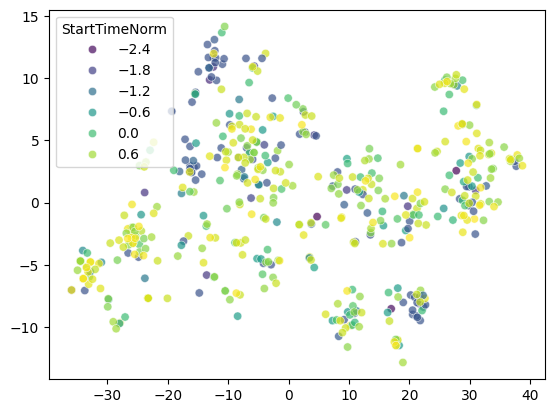

In [91]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=logs_with_time["StartTimeNorm"], palette='viridis', alpha=0.7)

In [ ]:
cross_val_score(lasso, X_tsne, logs_with_time["StartTimeNorm"], cv=5, scoring='neg_mean_squared_error')


array([-1.85201686, -2.28020902, -0.23841613, -0.61232236, -1.37837168])

In [94]:
cross_val_score(knn, X_tsne, logs_with_time["StartTimeNorm"], cv=5, scoring='neg_mean_squared_error')


array([-1.85835786, -2.4306103 , -0.53734084, -0.77129661, -1.36621885])

In [ ]:
cross_val_score(dummy, X_tsne, logs_with_time["StartTimeNorm"], cv=5, scoring='neg_mean_squared_error')

array([-1.83752829, -2.27006797, -0.23841613, -0.61232233, -1.37837162])